# Day 017: Rank of a Matrix (Measuring true information vs. noise)


## 1. Objective
> To programmatically calculate the rank of datasets and feature matrices to detect multicollinearity (redundant data) and ensure numerical stability before feeding data into machine learning algorithms.

## 2. Mathematical Foundation
> The **Rank** of a matrix $\mathbf{A}$, denoted as $\text{rank}(\mathbf{A})$, is the maximal number of linearly independent column vectors (or row vectors) in the matrix.   
> * **Linearly Independent:** No vector in the set can be expressed as a linear combination of the others.  
> * **Column Space (Span):** The set of all possible vectors that can be created by linear combinations of the columns. The rank is exactly equal to the geometric dimension of this column space (e.g., Rank 2 = a 2D plane).

## 3. Real-World & AI Applications
> * **Data Science (Multicollinearity Check):** In predictive modeling, if you include features that are linearly dependent (like having one column for Temperature in Celsius and another for Temperature in Fahrenheit), your matrix becomes rank deficient. This causes the Normal Equation $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ to fail because a rank-deficient matrix has a determinant of $0$ and cannot be inverted. Calculating rank helps you drop useless features.
>
> * **AI/ML Use Case (Dimensionality Reduction):** Large Language Models (LLMs) and computer vision models deal with matrices containing billions of parameters. Techniques like LoRA (Low-Rank Adaptation) freeze the massive original weights and only train a very small, low-rank approximation matrix. By recognizing that the "true information" rank is much lower than the actual parameter count, AI can be trained on consumer GPUs instead of massive server farms.

## 4. Algorithmic Strategy
> * **NumPy Function:** Use `np.linalg.matrix_rank(A)`.  
>   
> * **Under the Hood (SVD):** Do not write a rank algorithm using manual Gaussian Elimination (row reduction) in Python. Floating-point errors will turn exact zeros into `0.000000001`, making dependent rows look independent. NumPy's `matrix_rank` uses Singular Value Decomposition (SVD) and a tolerance threshold to safely filter out floating-point noise and find the true mathematical rank.

## 5. Implementation

In [1]:
import numpy as np

print("--- 1. Matrix Rank Analysis ---")

# Case 1: Full Rank (All features are unique)
# Feature 1: Website Clicks, Feature 2: Time on Page
A_full = np.array([[10, 120],
                   [15,  90],
                   [30, 200]])

rank_A = np.linalg.matrix_rank(A_full)
print("Matrix A (Full Rank - 2 Unique Features):")
print(A_full)
print(f"Rank: {rank_A} (Max possible is 2)\n")

# Case 2: Rank Deficient (Redundant Data)
# Feature 1: Item Price ($)
# Feature 2: Item Price (Cents) -> Exactly Feature 1 * 100
# Feature 3: Tax (10%) -> Exactly Feature 1 * 0.10
B_def = np.array([[ 5,  500, 0.5],
                  [10, 1000, 1.0],
                  [20, 2000, 2.0]])

rank_B = np.linalg.matrix_rank(B_def)
print("Matrix B (Rank Deficient - 3 Columns, but how much real data?):")
print(B_def)
print(f"Rank: {rank_B} (Max possible was 3. We have 2 columns of pure noise!)")

--- 1. Matrix Rank Analysis ---
Matrix A (Full Rank - 2 Unique Features):
[[ 10 120]
 [ 15  90]
 [ 30 200]]
Rank: 2 (Max possible is 2)

Matrix B (Rank Deficient - 3 Columns, but how much real data?):
[[5.e+00 5.e+02 5.e-01]
 [1.e+01 1.e+03 1.e+00]
 [2.e+01 2.e+03 2.e+00]]
Rank: 1 (Max possible was 3. We have 2 columns of pure noise!)


## 6. Verification

In [2]:
print("\n--- 2. The Danger of Floating Point Noise ---")
# Let's create a matrix that mathematically has a rank of 1.
# Row 2 is exactly Row 1 * 2.
C = np.array([[1.0, 3.0],
              [2.0, 6.0]])

# Now, we introduce a microscopic floating point error to one number.
C_noisy = np.array([[1.0, 3.0],
                    [2.0, 6.000000000000001]])

# NumPy's SVD-based rank solver is smart enough to handle a certain threshold of noise.
# But if the noise is bigger than the tolerance, it gets tricked into thinking it's new information.
print("Noisy Matrix C:")
print(C_noisy)
print(f"True Rank using SVD (default tolerance): {np.linalg.matrix_rank(C_noisy)}")

# If you use a strict tolerance, it counts the microscopic decimal as a totally unique dimension.
print(f"Tricked Rank (with zero tolerance): {np.linalg.matrix_rank(C_noisy, tol=0.0)}")


--- 2. The Danger of Floating Point Noise ---
Noisy Matrix C:
[[1. 3.]
 [2. 6.]]
True Rank using SVD (default tolerance): 1
Tricked Rank (with zero tolerance): 2


### Visualization

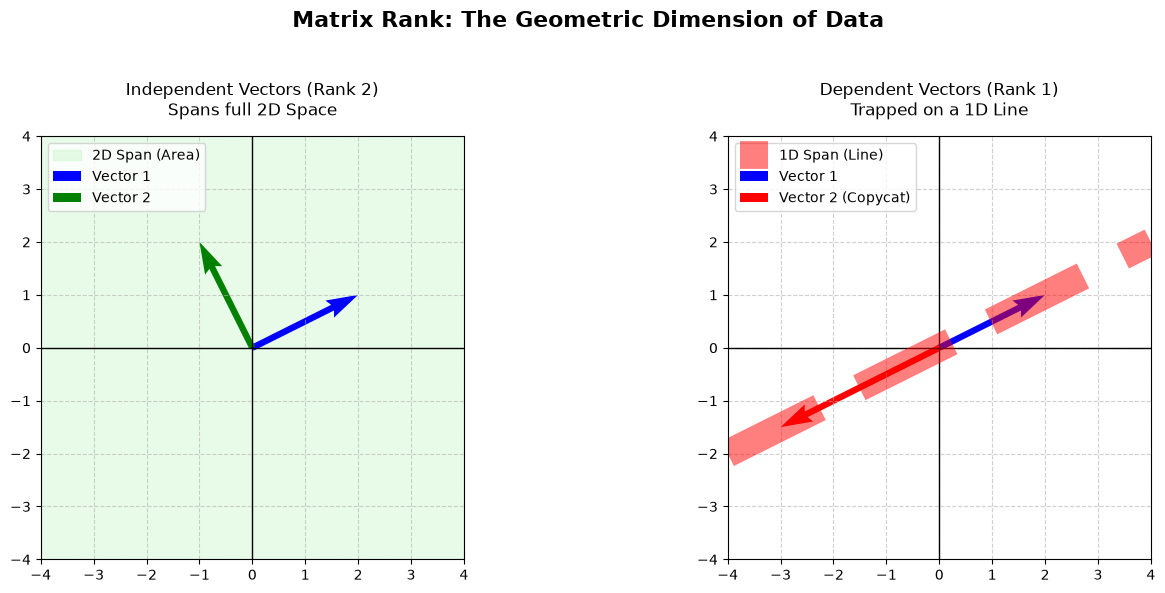

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Data Setup
# ==========================================

# Scenario 1: Independent Vectors (Rank 2)
v1 = np.array([2, 1])
v2 = np.array([-1, 2])
Matrix_Rank2 = np.column_stack((v1, v2))
rank2 = np.linalg.matrix_rank(Matrix_Rank2)

# Scenario 2: Dependent Vectors (Rank 1)
# u2 is just u1 scaled by -1.5
u1 = np.array([2, 1])
u2 = np.array([-3, -1.5])
Matrix_Rank1 = np.column_stack((u1, u2))
rank1 = np.linalg.matrix_rank(Matrix_Rank1)

# ==========================================
# Plotting
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Matrix Rank: The Geometric Dimension of Data", fontsize=16, weight='bold')

def setup_axis(ax, title):
    ax.set_title(title, pad=15)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_aspect('equal')

# --- Plot 1: Rank 2 Space ---
setup_axis(ax1, f"Independent Vectors (Rank {rank2})\nSpans full 2D Space")

# Draw the span (a polygon to represent the 2D plane they create)
ax1.fill([-4, 4, 4, -4], [-4, -4, 4, 4], color='lightgreen', alpha=0.2, label='2D Span (Area)')

# Draw the vectors
ax1.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.015, label='Vector 1')
ax1.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, label='Vector 2')
ax1.legend(loc='upper left')

# --- Plot 2: Rank 1 Space ---
setup_axis(ax2, f"Dependent Vectors (Rank {rank1})\nTrapped on a 1D Line")

# Draw the span (just a line)
x_vals = np.linspace(-4, 4, 10)
y_vals = 0.5 * x_vals  # The line y = 0.5x
ax2.plot(x_vals, y_vals, color='red', linestyle='--', alpha=0.5, linewidth=20, label='1D Span (Line)')

# Draw the vectors
ax2.quiver(0, 0, u1[0], u1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.015, label='Vector 1')
ax2.quiver(0, 0, u2[0], u2[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.015, label='Vector 2 (Copycat)')
ax2.legend(loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 7. Complexity Analysis
> * **Time Complexity:** $\mathcal{O}(\min(m \cdot n^2, m^2 \cdot n))$ because SVD is the most numerically stable way to compute rank for real-world messy data.
> * **Space Complexity:** $\mathcal{O}(m \cdot n)$ to store the decomposed singular value matrices.
